In [6]:
countrycode_file_path= r"C:\修論研究\VWT_historical_data\country_list.xlsx"
import pandas as pd
countrycode_df = pd.read_excel(countrycode_file_path)
countrycode_df.head()


,Country name,FAO code,Position,Reporting,Discontinuities,ISO3
0,Afghanistan,2,1,1,NaN,AFG
1,Albania,3,2,1,NaN,ALB
2,Algeria,4,3,1,NaN,DZA
3,American Samoa,5,4,0,NaN,ASM
4,Andorra,6,5,0,NaN,AND


# 一般化

# 海外領土とか無視、普通に国名で結び付け

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_1990.npy
Exporter index: 39 (iso3=CAN)

Top destinations (iso3, export):
    iso3        export
48   CHN  5.673500e+09
241  NAN  5.527534e+09
114  JPN  2.033019e+09
108  IRN  1.257216e+09
2    DZA  8.645236e+08
237  USA  8.627266e+08
60   CUB  7.451514e+08
208  ZAF  5.927278e+08
109  IRQ  5.803220e+08
179  PHL  5.666872e+08
121  KOR  5.243574e+08
112  ITA  4.779646e+08
17   BGD  4.558210e+08
244  VEN  4.527470e+08
235  GBR  4.273579e+08
107  IDN  3.285738e+08
52   COL  3.243448e+08
21   NAN  3.117319e+08
153  MAR  1.900539e+08
49   TWN  1.861363e+08
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)


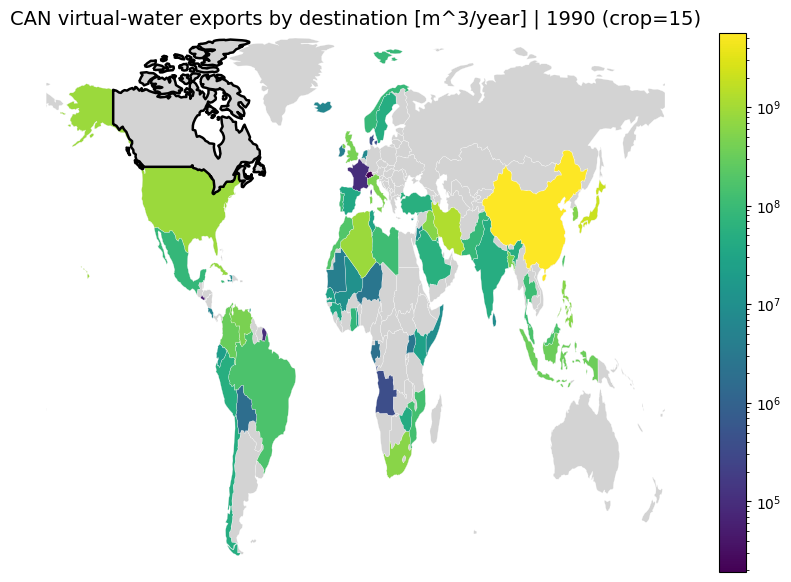

In [24]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _normalize_zip_shp_path(p: str) -> str:
    # "xxx.zip!yyy.shp" -> "zip://xxx.zip!yyy.shp"
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Natural Earth は国によって ISO_A3 が -99（欠損）になるので、
    ISO_A3 -> ADM0_A3 -> SOV_A3 の順でフォールバックして _iso3 を作る。
    """
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    # 1) primary: ISO_A3
    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 2) fallback: ADM0_A3
    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # 3) fallback: SOV_A3
    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    # cleanup
    world.loc[invalid, "_iso3"] = np.nan

    # 代表的例外（必要なら増やす）
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})

    return world

def plot_vwt_exports_by_destination(
    exporter_iso3: str,
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    use_log=True,
    top_n_print=20,
    unit="m^3/year",
):
    """
    VWTmat: row=exporter, col=importer 前提。
    country_list.xlsx は VWTmat の国順と一致している前提。
    world map のキーは ISO_A3 の欠損(-99)を考慮してフォールバックで作る。
    """

    exporter_iso3 = str(exporter_iso3).strip().upper()

    # -------------------------
    # 1) Load VWT matrix
    # -------------------------
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    if VWTmat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={VWTmat.shape}")

    if VWTmat.shape[0] != VWTmat.shape[1]:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    N = VWTmat.shape[0]

    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # -------------------------
    # 2) Load country list
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    # ISO3列を自動検出（country_list側）
    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    # exporter index を ISO3で決める
    hit = clN.index[clN["_iso3"] == exporter_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・exporter_iso3の表記(CANなど)が正しいか を確認して。"
        )
    exporter_index = int(hit[0])
    print("Exporter index:", exporter_index, f"(iso3={exporter_iso3})")

    # -------------------------
    # 3) Export vector (destinations)
    # -------------------------
    exports = VWTmat[exporter_index, :].astype(float)

    dest = pd.DataFrame({"iso3": clN["_iso3"].values, "export": exports})
    dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)

    print("\nTop destinations (iso3, export):")
    print(dest_pos.head(top_n_print))

    # -------------------------
    # 4) Load world map（★修正点：zipパス + robust iso3 key）
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # -------------------------
    # 5) Merge
    # -------------------------
    m = world.merge(dest, left_on="_iso3", right_on="iso3", how="left")

    # -------------------------
    # 6) Plot
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"{exporter_iso3} virtual-water exports by destination [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    # base
    m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

    pos = m["export"].fillna(0) > 0
    if pos.any():
        if use_log:
            vmin = float(m.loc[pos, "export"].min())
            vmax = float(m.loc[pos, "export"].max())
            vmin = max(vmin, 1e-12)  # LogNormはvmin>0必須

            m.loc[pos].plot(
                ax=ax,
                column="export",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
        else:
            m.loc[pos].plot(
                ax=ax,
                column="export",
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
    else:
        print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う等を疑う）")

    # highlight exporter boundary
    src = m[m["_iso3"] == exporter_iso3]
    if len(src) > 0:
        src.boundary.plot(ax=ax, linewidth=1.8, color="black")
    else:
        print("[WARN] exporter が地図側で見つからない（キー列にその国が無い/特殊コードの可能性）")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return dest_pos, m


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

dest_pos, merged_map = plot_vwt_exports_by_destination(
    exporter_iso3="CAN",
    year=1990,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    top_n_print=20,
)

# ソ連をロシアにする処理をした

VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy
Exporter index: 187 (iso3=RUS)

Top destinations (iso3, export):
    iso3_raw        export iso3
69       EGY  7.894133e+09  EGY
228      TUR  5.428603e+09  TUR
108      IRN  2.660091e+09  IRN
14       AZE  2.163126e+09  AZE
208      ZAF  1.614419e+09  ZAF
17       BGD  1.552649e+09  BGD
165      NGA  1.507624e+09  NGA
249      YEM  1.184531e+09  YEM
85       GEO  8.502850e+08  GEO
118      KEN  8.289661e+08  KEN
234      ARE  7.160669e+08  ARE
129      LBY  6.989616e+08  LBY
111      ISR  6.512274e+08  ISR
126      LBN  6.240686e+08  LBN
220      TZA  5.674545e+08  TZA
116      JOR  5.014606e+08  JOR
107      IDN  4.535715e+08  IDN
171      OMN  4.203221e+08  OMN
211      LKA  4.111304e+08  LKA
125      LVA  4.029922e+08  LVA
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)


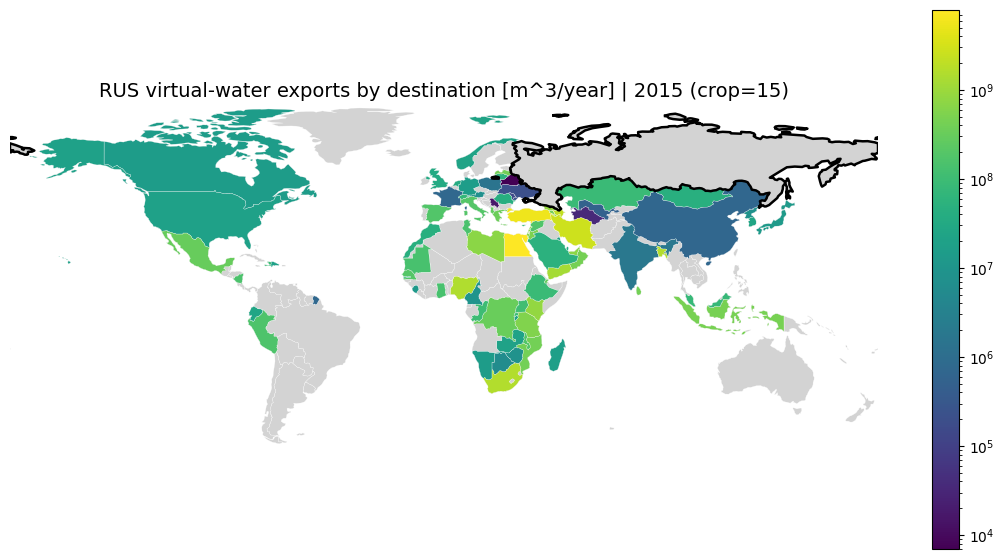

In [20]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def _normalize_zip_shp_path(p: str) -> str:
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    world.loc[invalid, "_iso3"] = np.nan
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})
    return world

def plot_vwt_exports_by_destination(
    exporter_iso3: str,
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    xlim=(-180, 180),
    ylim=(-60, 85),
    use_log=True,
    top_n_print=20,
    unit="m^3/year",
    ussr_until_year=1991,  # <=1991 は USSR を RUS として扱う
):
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    exporter_iso3 = str(exporter_iso3).strip().upper()
    if exporter_iso3 in USSR_ALIASES:
        exporter_iso3 = "RUS"

    # 1) Load VWT matrix
    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    VWTmat = np.load(vwt_path).astype(float)

    if VWTmat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={VWTmat.shape}")
    if VWTmat.shape[0] != VWTmat.shape[1]:
        print(f"[WARN] VWTmat is not square: {VWTmat.shape}. row/colの向きを要確認")

    N = VWTmat.shape[0]
    print("VWTmat shape:", VWTmat.shape)
    print("VWT file:", vwt_path)

    # 2) Load country list
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA", "UK": "GBR", "EL": "GRC", "SP": "ESP",
        "SW": "SWE", "NO": "NOR", "JA": "JPN", "KO": "KOR", "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    # --- ここが重要: ISO3欠損のUSSRを国名で補完 ---
    country_name_col = None
    for c in clN.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = clN.columns[0]

    clN["_country_upper"] = clN[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    pre_ussr = int(year) <= int(ussr_until_year)
    has_ussr_row = clN["_iso3"].isin(USSR_ALIASES).any()

    # exporter index（RUSは1991以前USSR優先）
    if exporter_iso3 == "RUS":
        rus_hits = clN.index[clN["_iso3"] == "RUS"]
        ussr_hits = clN.index[clN["_iso3"].isin(USSR_ALIASES)]

        if pre_ussr and len(ussr_hits) > 0:
            exporter_index = int(ussr_hits[0])
            print(f"Exporter index: {exporter_index} (requested=RUS, used=USSR for year<={ussr_until_year})")
        elif len(rus_hits) > 0:
            exporter_index = int(rus_hits[0])
            print("Exporter index:", exporter_index, "(iso3=RUS)")
        elif len(ussr_hits) > 0:
            exporter_index = int(ussr_hits[0])
            print(f"[WARN] RUSが無いためUSSRを使用: index={exporter_index}")
        else:
            raise ValueError("RUS/USSR が country_list の先頭N行に見つからない。")
    else:
        hit = clN.index[clN["_iso3"] == exporter_iso3]
        if len(hit) == 0:
            raise ValueError(
                f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。\n"
                f"・country_listがVWT順になっているか\n"
                f"・ISO3列の中身が正しいか\n"
                f"・exporter_iso3の表記(CANなど)が正しいか を確認して。"
            )
        exporter_index = int(hit[0])
        print("Exporter index:", exporter_index, f"(iso3={exporter_iso3})")

    # 3) Export vector (destinations)
    exports = VWTmat[exporter_index, :].astype(float)
    dest = pd.DataFrame({"iso3_raw": clN["_iso3"].values, "export": exports})

    # 1991年以前は destination 側のUSSRもRUSに統合
    if pre_ussr and has_ussr_row:
        dest["iso3"] = dest["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        dest = dest.groupby("iso3", as_index=False)["export"].sum()
    else:
        dest["iso3"] = dest["iso3_raw"]

    dest = dest[~dest["iso3"].isin(["", "NAN", "NONE"])].copy()
    dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)

    print("\nTop destinations (iso3, export):")
    print(dest_pos.head(top_n_print))

    # 4) Load world map
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    # 5) Merge
    m = world.merge(dest[["iso3", "export"]], left_on="_iso3", right_on="iso3", how="left")

    # 6) Plot
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(
        f"{exporter_iso3} virtual-water exports by destination [{unit}] | {year} (crop={crop})",
        fontsize=14
    )

    m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

    pos = m["export"].fillna(0) > 0
    if pos.any():
        if use_log:
            vmin = float(m.loc[pos, "export"].min())
            vmax = float(m.loc[pos, "export"].max())
            vmin = max(vmin, 1e-12)
            vmax = max(vmax, vmin * (1.0 + 1e-12))  # LogNorm安全策

            m.loc[pos].plot(
                ax=ax,
                column="export",
                norm=LogNorm(vmin=vmin, vmax=vmax),
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
        else:
            m.loc[pos].plot(
                ax=ax,
                column="export",
                linewidth=0.2,
                edgecolor="white",
                legend=True,
            )
    else:
        print("[WARN] export > 0 が1つも無い（向きが逆、year/cropが違う等を疑う）")

    src = m[m["_iso3"] == exporter_iso3]
    if len(src) > 0:
        src.boundary.plot(ax=ax, linewidth=1.8, color="black")
    else:
        print("[WARN] exporter が地図側で見つからない（キー列にその国が無い/特殊コードの可能性）")

   

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    plt.show()

    return dest_pos, m


# 使い方
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

dest_pos, merged_map = plot_vwt_exports_by_destination(
    exporter_iso3="RUS",   # 1991以前はUSSRを自動採用
    year=2015,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    top_n_print=20,
)


# 30年のアニメーションをつくりたい。（国、作物）ソ連崩壊以前のロシアなど反映されていないことに注意

Exporter index: 39 (iso3=CAN)
N: 255


MovieWriter ffmpeg unavailable; using Pillow instead.


Global scale: vmin=1062.81, vmax=1.83249e+10 (use_log=True)

Top destinations in first frame:
    iso3        export
241  NAN  6.192994e+09
48   CHN  3.163017e+09
114  JPN  1.950486e+09
60   CUB  1.477154e+09
30   BRA  1.244895e+09
121  KOR  9.810526e+08
112  ITA  7.913007e+08
109  IRQ  7.363005e+08
235  GBR  6.894387e+08
69   EGY  4.934792e+08

Top destinations in first frame:
    iso3        export
241  NAN  6.192994e+09
48   CHN  3.163017e+09
114  JPN  1.950486e+09
60   CUB  1.477154e+09
30   BRA  1.244895e+09
121  KOR  9.810526e+08
112  ITA  7.913007e+08
109  IRQ  7.363005e+08
235  GBR  6.894387e+08
69   EGY  4.934792e+08
Saved GIF: C:\修論研究\VWT_historical_data\CAN_crop15_1986_2016_export.gif

Top destinations in first frame:
    iso3        export
241  NAN  6.192994e+09
48   CHN  3.163017e+09
114  JPN  1.950486e+09
60   CUB  1.477154e+09
30   BRA  1.244895e+09
121  KOR  9.810526e+08
112  ITA  7.913007e+08
109  IRQ  7.363005e+08
235  GBR  6.894387e+08
69   EGY  4.934792e+08


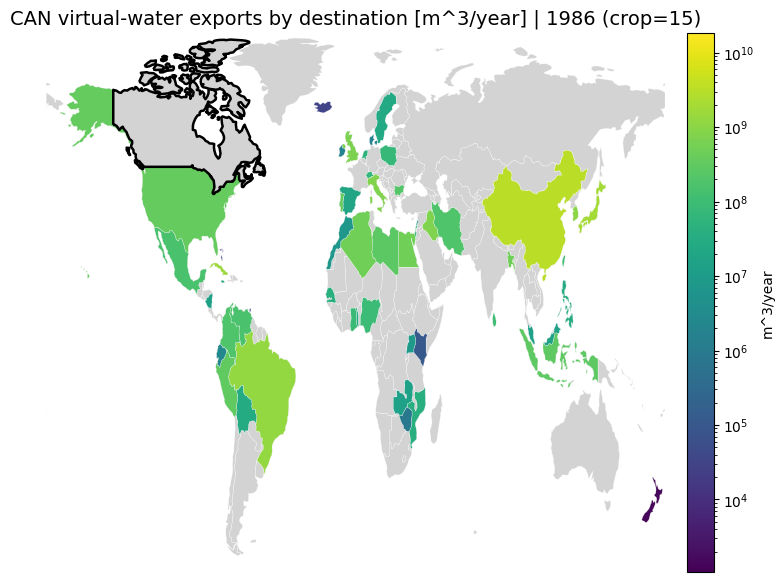

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    """
    gpd.read_file() が読めるように、"xxx.zip!yyy.shp" を "zip://xxx.zip!yyy.shp" に寄せる。
    すでに zip:// が付いてたらそのまま。
    """
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def animate_vwt_exports_by_destination(
    exporter_iso3: str,
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,     # r"...\VWT_npy\VWT_{crop}_{year}.npy"
    ne_countries_shp: str,     # r"...\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"
    use_log: bool = True,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,  # Noneならfpsから自動
    out_mp4: str | None = None,      # 例: r"C:\...\CAN_crop15_1986_2016.mp4"
    out_gif: str | None = None,      # 例: r"C:\...\CAN_crop15_1986_2016.gif"
    dpi: int = 150,
    top_n_print: int = 10,
):
    """
    - exporter_iso3, crop は固定
    - year_start..year_end をアニメ化
    - カラーバーは全期間で固定スケール（global vmin/vmax）
    """
    exporter_iso3 = str(exporter_iso3).strip().upper()
    years = list(range(int(year_start), int(year_end) + 1))
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    # -------------------------
    # 1) country_list & exporter index
    # -------------------------
    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        if str(c).strip().lower() in ["iso3", "iso_a3", "iso-3", "iso_3"]:
            iso3_col = c
            break
    if iso3_col is None:
        for c in cl.columns:
            if "iso3" in str(c).strip().lower():
                iso3_col = c
                break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    # N はVWTのサイズに合わせたいので、まず最初の年を読んでN確定
    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    N = vwt0.shape[0]
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    hit = clN.index[clN["_iso3"] == exporter_iso3]
    if len(hit) == 0:
        raise ValueError(
            f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。\n"
            f"・country_listがVWT順になっているか\n"
            f"・ISO3列の中身が正しいか\n"
            f"・exporter_iso3の表記(USA/JPNなど)が正しいか を確認して。"
        )
    exporter_index = int(hit[0])
    print("Exporter index:", exporter_index, f"(iso3={exporter_iso3})")
    print("N:", N)

    # -------------------------
    # 2) world map load
    # -------------------------
    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = world["ISO_A3"].astype(str).str.strip().str.upper()
    world.loc[world["_iso3"].isin(["-99", "NAN", "NONE", ""]), "_iso3"] = np.nan

    # exporter boundary 用（固定）
    src_geom = world.loc[world["_iso3"] == exporter_iso3]
    if len(src_geom) == 0:
        print("[WARN] exporter が地図側で見つからない（ISO_A3にその国が無い/特殊コードの可能性）")

    # -------------------------
    # 3) preload exports (all years) + global vmin/vmax
    # -------------------------
    exports_by_year = {}
    global_pos_vals = []

    for y in years:
        vwt_path = vwt_npy_template.format(crop=crop, year=y)
        VWTmat = np.load(vwt_path).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        exports = VWTmat[exporter_index, :].astype(float)
        exports_by_year[y] = exports

        pos = exports[exports > 0]
        if pos.size > 0:
            global_pos_vals.append(pos)

    if len(global_pos_vals) == 0:
        raise ValueError("[ERROR] 全年で export>0 が1つも無い（row/colの向き、crop/year、exporter_indexなど要確認）")

    global_pos_vals = np.concatenate(global_pos_vals)
    vmin = float(np.min(global_pos_vals))
    vmax = float(np.max(global_pos_vals))
    if vmin <= 0:
        # LogNormはvmin>0必須
        vmin = float(np.min(global_pos_vals[global_pos_vals > 0]))

    print(f"Global scale: vmin={vmin:g}, vmax={vmax:g} (use_log={use_log})")

    if use_log:
        norm = LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    # -------------------------
    # 4) figure & fixed colorbar
    # -------------------------
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm)  # cmapはGeoPandas側のデフォルトに合わせるより、明示したいならここで cmap=...
    sm.set_array([])  # Matplotlibの都合
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(unit)

    # -------------------------
    # 5) animation update
    # -------------------------
    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(
            f"{exporter_iso3} virtual-water exports by destination [{unit}] | {y} (crop={crop})",
            fontsize=14
        )

        exports = exports_by_year[y]
        dest = pd.DataFrame({"iso3": clN["_iso3"].values, "export": exports})

        # TopNプリント（重いならコメントアウト）
        if top_n_print and top_n_print > 0 and frame_i == 0:
            dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)
            print("\nTop destinations in first frame:")
            print(dest_pos.head(top_n_print))

        m = world.merge(dest, left_on="_iso3", right_on="iso3", how="left")

        # base
        m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

        pos = m["export"].fillna(0) > 0
        if pos.any():
            m.loc[pos].plot(
                ax=ax,
                column="export",
                norm=norm,              # ★固定スケール
                linewidth=0.2,
                edgecolor="white",
                legend=False,           # カラーバーは固定で別に付けたのでFalse
            )

        # exporter boundary
        if len(src_geom) > 0:
            src_geom.boundary.plot(ax=ax, linewidth=1.8, color="black")

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=len(years),
        interval=interval_ms,
        blit=False
    )

    # -------------------------
    # 6) save (optional)
    # -------------------------
    if out_mp4:
        # mp4保存はffmpegが必要
        anim.save(out_mp4, fps=fps, dpi=dpi)
        print("Saved MP4:", out_mp4)

    if out_gif:
        # gif保存はpillowが必要
        anim.save(out_gif, fps=fps, dpi=dpi)
        print("Saved GIF:", out_gif)

    #plt.show()
    return anim


# =========================
# 使い方（ここだけ変えればOK）
# =========================
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_exports_by_destination(
    exporter_iso3="CAN",
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\CAN_crop15_1986_2016_export.gif",
)

# 1991年以降のロシアはソ連にする

Exporter index (RUS mode): pre<=1991 -> 241, post -> 187
N: 255
world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)


MovieWriter ffmpeg unavailable; using Pillow instead.


Global scale: vmin=1830.81, vmax=1.23411e+10 (use_log=True)

Top destinations in first frame:
    iso3        export
46   CUB  2.264092e+09
1    AFG  1.708899e+08
172  ROU  4.189936e+07

Top destinations in first frame:
    iso3        export
46   CUB  2.264092e+09
1    AFG  1.708899e+08
172  ROU  4.189936e+07
Saved GIF: C:\修論研究\VWT_historical_data\RUS_crop15_1986_2016_export.gif

Top destinations in first frame:
    iso3        export
46   CUB  2.264092e+09
1    AFG  1.708899e+08
172  ROU  4.189936e+07


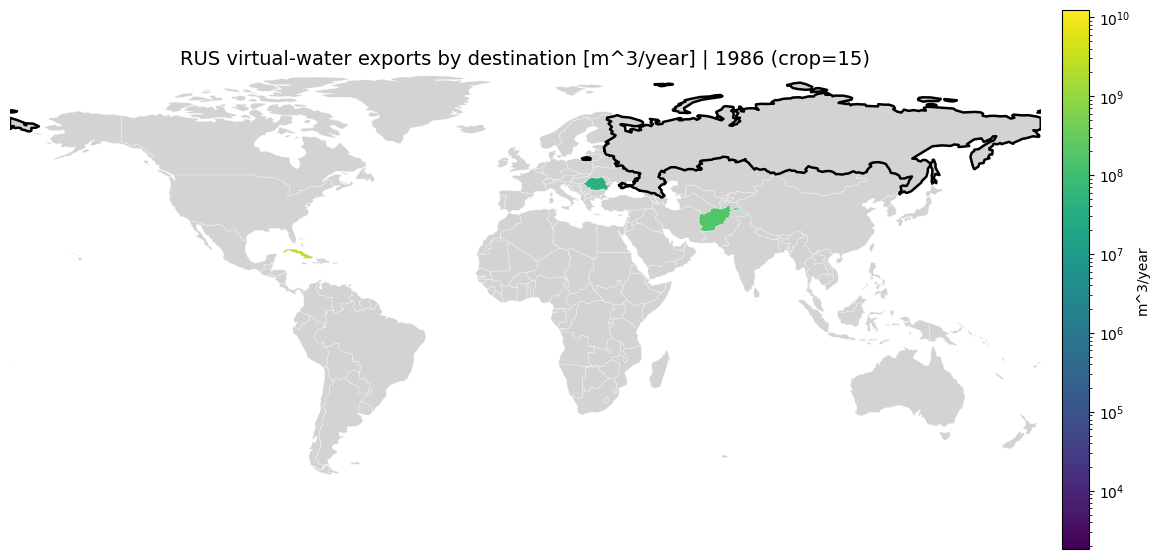

In [18]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.animation import FuncAnimation

def _normalize_zip_shp_path(p: str) -> str:
    p = str(p)
    if p.startswith("zip://"):
        return p
    if ".zip!" in p.lower():
        return "zip://" + p
    return p

def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    def _clean(s):
        return s.astype(str).str.strip().str.upper()

    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world["_iso3"] = _clean(world["ISO_A3"])
    invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isin(["-99", "NAN", "NONE", ""])

    world.loc[invalid, "_iso3"] = np.nan
    world["_iso3"] = world["_iso3"].replace({"FR1": "FRA"})
    return world

def animate_vwt_exports_by_destination(
    exporter_iso3: str,
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    use_log: bool = True,
    xlim=(-180, 180),
    ylim=(-60, 85),
    unit="m^3/year",
    fps: int = 6,
    interval_ms: int | None = None,
    out_mp4: str | None = None,
    out_gif: str | None = None,
    dpi: int = 150,
    top_n_print: int = 10,
    cmap: str = "viridis",
    ussr_until_year: int = 1991,
):
    USSR_ALIASES = {"USSR", "SUN", "USS"}
    USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

    exporter_iso3 = str(exporter_iso3).strip().upper()
    if exporter_iso3 in USSR_ALIASES:
        exporter_iso3 = "RUS"

    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定して。")
    if interval_ms is None:
        interval_ms = int(1000 / max(1, fps))

    cl = pd.read_excel(country_list_xlsx)

    iso3_col = None
    for c in cl.columns:
        low = str(c).strip().lower()
        if low in ["iso3", "iso_a3", "iso-3", "iso_3"] or "iso3" in low:
            iso3_col = c
            break
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")

    N = vwt0.shape[0]
    if len(cl) < N:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({N}). country_listの行数が足りない。")

    clN = cl.iloc[:N].copy()
    clN["_iso3"] = clN[iso3_col].astype(str).str.strip().str.upper()

    ISO3_FIX = {
        "FR": "FRA", "UK": "GBR", "EL": "GRC", "SP": "ESP",
        "SW": "SWE", "NO": "NOR", "JA": "JPN", "KO": "KOR", "CH": "CHN",
    }
    clN["_iso3"] = clN["_iso3"].replace(ISO3_FIX)

    country_name_col = None
    for c in clN.columns:
        low = str(c).strip().lower()
        if low in ["country name", "country", "name"]:
            country_name_col = c
            break
    if country_name_col is None:
        country_name_col = clN.columns[0]

    clN["_country_upper"] = clN[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = clN["_iso3"].isin(["", "NAN", "NONE"])
    clN.loc[missing_iso & clN["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    if exporter_iso3 == "RUS":
        rus_hits = clN.index[clN["_iso3"] == "RUS"]
        ussr_hits = clN.index[clN["_iso3"].isin(USSR_ALIASES)]

        if len(rus_hits) == 0 and len(ussr_hits) == 0:
            raise ValueError("RUS/USSR が country_list の先頭N行に見つからない。")

        idx_post = int(rus_hits[0]) if len(rus_hits) > 0 else int(ussr_hits[0])
        idx_pre = int(ussr_hits[0]) if len(ussr_hits) > 0 else idx_post
        print(f"Exporter index (RUS mode): pre<={ussr_until_year} -> {idx_pre}, post -> {idx_post}")
    else:
        hit = clN.index[clN["_iso3"] == exporter_iso3]
        if len(hit) == 0:
            raise ValueError(f"exporter_iso3={exporter_iso3} が country_list の先頭N行に見つからない。")
        idx_post = int(hit[0])
        idx_pre = idx_post
        ussr_hits = []
        print("Exporter index:", idx_post, f"(iso3={exporter_iso3})")

    print("N:", N)

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    print("world iso key: ISO_A3 -> ADM0_A3 -> SOV_A3 (fallback)")

    src_geom = world.loc[world["_iso3"] == exporter_iso3]
    if len(src_geom) == 0:
        print("[WARN] exporter が地図側で見つからない（キー列にその国が無い/特殊コードの可能性）")

    dest_by_year = {}
    global_pos_vals = []

    for y in years:
        VWTmat = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if VWTmat.shape[0] != N or VWTmat.shape[1] != N:
            raise ValueError(f"年{y}のVWTサイズが一致しない: {VWTmat.shape} (expected {N}x{N})")

        use_pre = (exporter_iso3 == "RUS" and y <= int(ussr_until_year) and len(ussr_hits) > 0)
        exporter_index = idx_pre if use_pre else idx_post

        # 輸出: row=exporter
        exports = VWTmat[exporter_index, :].astype(float)
        dest = pd.DataFrame({"iso3": clN["_iso3"].values, "export": exports})

        if use_pre:
            dest["iso3"] = dest["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

        dest = dest[~dest["iso3"].isin(["", "NAN", "NONE"])].copy()
        dest = dest.groupby("iso3", as_index=False)["export"].sum()

        dest_by_year[y] = dest

        pos = dest.loc[dest["export"] > 0, "export"].to_numpy()
        if pos.size > 0:
            global_pos_vals.append(pos)

    if len(global_pos_vals) == 0:
        raise ValueError("[ERROR] 全年で export>0 が1つも無い。")

    global_pos_vals = np.concatenate(global_pos_vals)
    vmin = float(np.min(global_pos_vals))
    vmax = float(np.max(global_pos_vals))
    if use_log:
        vmin = max(vmin, 1e-12)
    if vmax <= vmin:
        vmax = vmin * (1.0 + 1e-9)

    print(f"Global scale: vmin={vmin:g}, vmax={vmax:g} (use_log={use_log})")
    norm = LogNorm(vmin=vmin, vmax=vmax) if use_log else Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(unit)

    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        ax.set_title(f"{exporter_iso3} virtual-water exports by destination [{unit}] | {y} (crop={crop})", fontsize=14)

        dest = dest_by_year[y]

        if top_n_print and top_n_print > 0 and frame_i == 0:
            dest_pos = dest[dest["export"] > 0].sort_values("export", ascending=False)
            print("\nTop destinations in first frame:")
            print(dest_pos.head(top_n_print))

        m = world.merge(dest, left_on="_iso3", right_on="iso3", how="left")
        m.plot(ax=ax, color="lightgrey", linewidth=0.2, edgecolor="white")

        pos = m["export"].fillna(0) > 0
        if pos.any():
            m.loc[pos].plot(
                ax=ax,
                column="export",
                cmap=cmap,
                norm=norm,
                linewidth=0.2,
                edgecolor="white",
                legend=False,
            )

        if len(src_geom) > 0:
            src_geom.boundary.plot(ax=ax, linewidth=1.8, color="black")

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        return []

    anim = FuncAnimation(fig, update, frames=len(years), interval=interval_ms, blit=False)

    if out_mp4:
        anim.save(out_mp4, fps=fps, dpi=dpi)
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(out_gif, fps=fps, dpi=dpi)
        print("Saved GIF:", out_gif)

    return anim


# 使い方
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

anim = animate_vwt_exports_by_destination(
    exporter_iso3="RUS",
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    use_log=True,
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\RUS_crop15_1986_2016_export.gif",
)
